# Data Acquisition and Exploration

## Objective
The objective of this section is to obtain the Iris dataset, load it into Python, and explore its structure before training a machine learning model.

The Iris dataset contains measurements of flowers and their species labels.

### Dataset Features
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

### Target Classes
- Iris-setosa
- Iris-versicolor
- Iris-virginica

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

from sklearn.datasets import load_iris

import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Load Dataset

In this step, the Iris dataset is loaded into Python.

In [2]:
# Dataset URL

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# Column names

columns = [
    "Sepal_Length",
    "Sepal_Width",
    "Petal_Length",
    "Petal_Width",
    "Species"
]

# Load dataset

df = pd.read_csv(
    url,
    names=columns
)

# Display first rows

df.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Step 3: Identify Input Features and Target Variable

The dataset is separated into:

- Input Features (X) flower measurements
- Target Variable (y)  flower species

This prepares the data for machine learning.

In [4]:
# Define X and y

X = df.drop("Species", axis=1)

y = df["Species"]

print("Input Features")
print(X.columns)

print("\nTarget Variable")
print(y.name)

Input Features
Index(['Sepal_Length', 'Sepal_Width', 'Petal_Length', 'Petal_Width'], dtype='object')

Target Variable
Species


## Explanation

The `drop()` function removes the target column and stores the remaining columns as input features (X).

The target column `Species` is stored separately as y because it contains the flower classes that the model will predict.


The dataset was successfully divided into input variables and the target variable for model training.

# (b) Model Training and Testing

This section trains a Decision Tree classifier and evaluates its accuracy.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

## Step 1: Split Dataset

80% of data will be used for training.

20% will be used for testing.

In [6]:
# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Size:", len(X_train))
print("Testing Size:", len(X_test))

Training Size: 120
Testing Size: 30


In [7]:
# Train model using Gini Index

model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [8]:
# Accuracy

accuracy = model.score(
    X_test,
    y_test
)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 100.0 %


## Explanation

Train-test splitting helps evaluate how well the model performs on unseen data.

Training data teaches the model patterns while testing data measures performance.

## Summary

The Decision Tree model was trained using the Gini Index and evaluated using accuracy.

# (c) Performance Evaluation

This section evaluates prediction performance.

In [9]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score
)

In [10]:
# Predictions

y_pred = model.predict(X_test)

print(y_pred)

['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']


In [11]:
# Confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

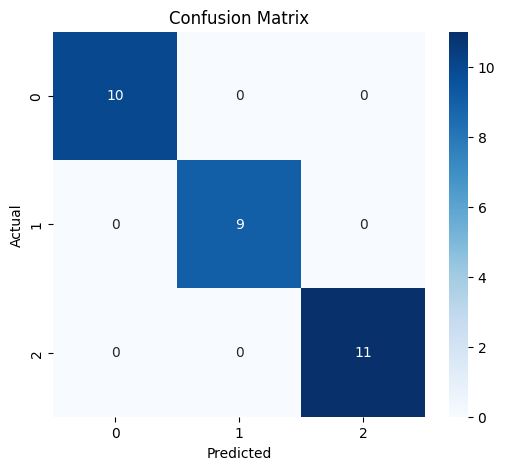

In [12]:
# Visualize confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Interpretation

The confusion matrix shows correct and incorrect classifications.

Values along the diagonal represent correctly predicted flower species.

Higher diagonal values indicate better model performance.

## Summary

Model performance was measured using predictions, confusion matrix, and accuracy.

# (d) Decision Tree Visualization

This section visualizes how the model makes decisions.

In [14]:
from sklearn.tree import plot_tree

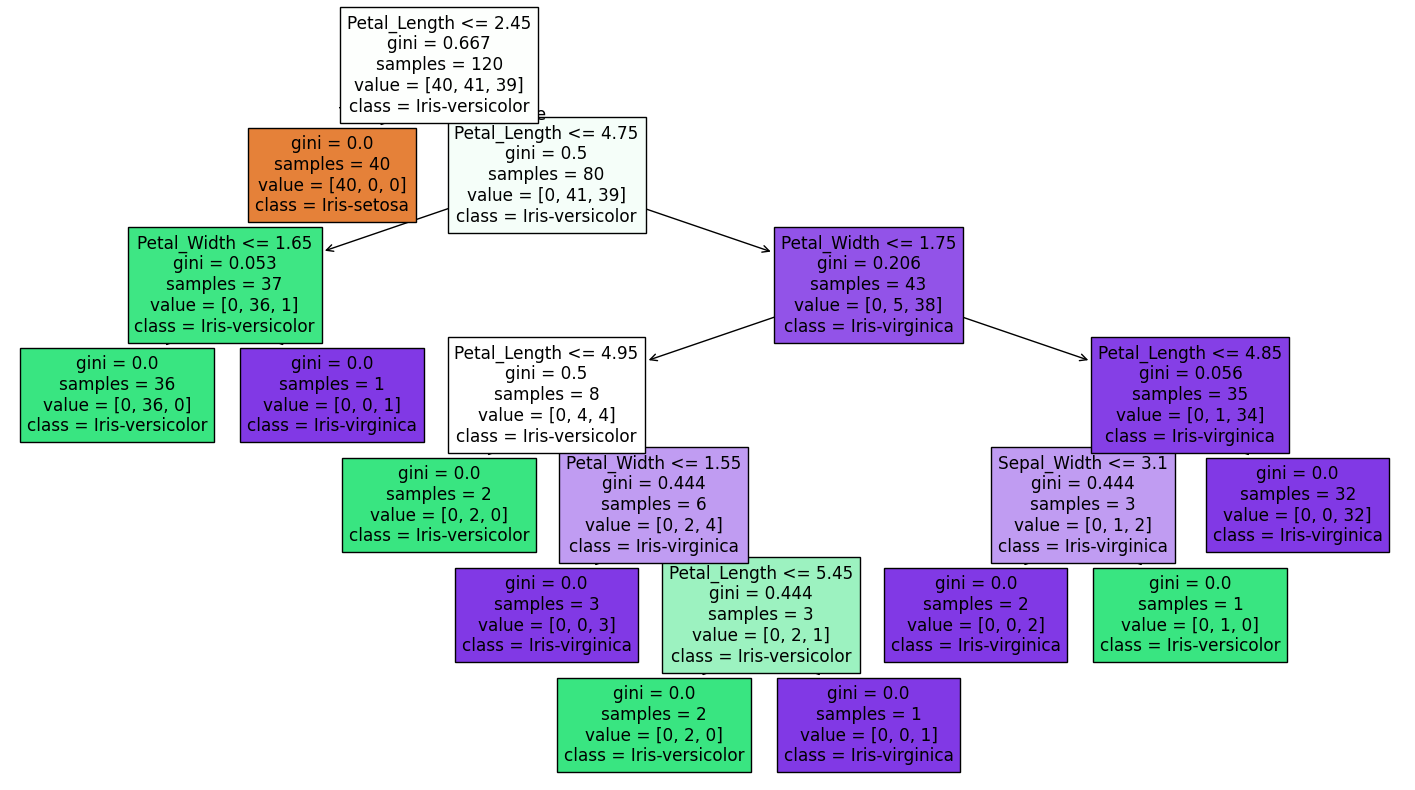

In [15]:
# Plot Decision Tree

plt.figure(
    figsize=(18,10)
)

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)

plt.show()

In [16]:
# Root node

print(
    "Root Node Feature:"
)

print(
    X.columns[
        model.tree_.feature[0]
    ]
)

Root Node Feature:
Petal_Length


## Explanation

The decision tree starts at the root node and applies conditions to split the data.

Each split reduces impurity using the Gini Index.

The model follows branches until reaching a leaf node where the final class prediction is made.

## Summary

Decision tree visualization helped explain how classification decisions are made.

# Conclusion

The Iris dataset was successfully explored, split into training and testing sets, and used to train a Decision Tree classifier.

Performance evaluation showed the effectiveness of the model using accuracy and confusion matrix.

Decision tree visualization illustrated how classification decisions are made.